# Fraud Detection Project
### Credit Card Transactions Fraud Detection
**Target:** `is_fraud` — 0 = Not Fraud, 1 = Fraud

In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


In [2]:
# ============================================================
# Load Data
# ============================================================

train_df = pd.read_csv("data/fraudTrain.csv")
test_df  = pd.read_csv("data/fraudTest.csv")

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (1296675, 23)
Test shape:  (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
# ============================================================
#  Dataset Overview
# ============================================================

print('Train dataset information:')
train_df.info()

print('\nTest dataset information:')
test_df.info()

print('\nTrain columns:')
print(train_df.columns.tolist())

print('\nTrain basic statistics:')
display(train_df.describe().T)

print('\nMissing values in train:')
missing_report = pd.DataFrame({
    'missing_count':      train_df.isnull().sum(),
    'missing_percentage': train_df.isnull().mean() * 100,
    'dtype':              train_df.dtypes
})
display(missing_report)

Train dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  floa

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01



Missing values in train:


,missing_count,missing_percentage,dtype
Unnamed: 0,0,0.0,int64
trans_date_trans_time,0,0.0,object
cc_num,0,0.0,int64
merchant,0,0.0,object
category,0,0.0,object
amt,0,0.0,float64
first,0,0.0,object
last,0,0.0,object
gender,0,0.0,object
street,0,0.0,object


,count,percentage
Not Fraud,1289169,99.421135
Fraud,7506,0.578865


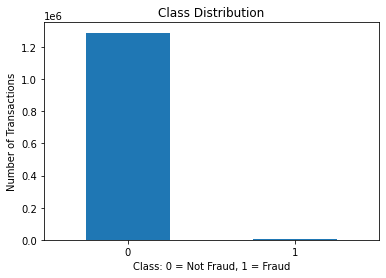

Fraud percentage in training data: 0.5789%


In [4]:
# ============================================================
#  Target Distribution (Class Imbalance)
# ============================================================

target_summary = pd.DataFrame({
    'count':      train_df['is_fraud'].value_counts().sort_index(),
    'percentage': train_df['is_fraud'].value_counts(normalize=True).sort_index() * 100
})
target_summary.index = ['Not Fraud', 'Fraud']
display(target_summary)

plt.figure(figsize=(6, 4))
train_df['is_fraud'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class: 0 = Not Fraud, 1 = Fraud')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

fraud_pct = train_df['is_fraud'].mean() * 100
print(f'Fraud percentage in training data: {fraud_pct:.4f}%')

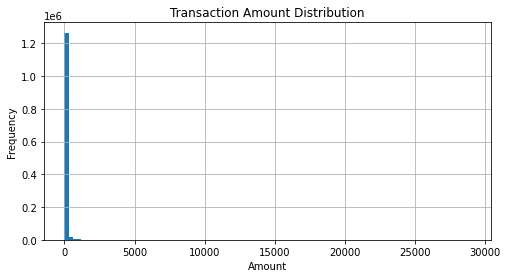

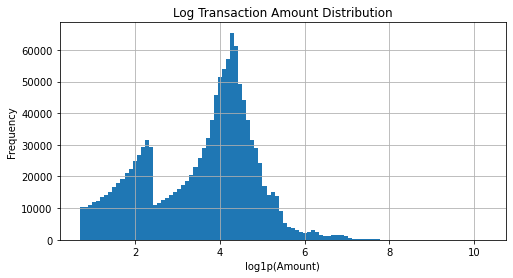

,count,mean,median,std,min,max
is_fraud,,,,,,
0,1289169,67.667110,47.280,154.007971,1.00,28948.90
1,7506,531.320092,396.505,390.560070,1.06,1376.04


In [5]:
# ============================================================
# EDA: Transaction Amount
# ============================================================

plt.figure(figsize=(8, 4))
train_df['amt'].hist(bins=100)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 4))
np.log1p(train_df['amt']).hist(bins=100)
plt.title('Log Transaction Amount Distribution')
plt.xlabel('log1p(Amount)')
plt.ylabel('Frequency')
plt.show()

amount_by_class = train_df.groupby('is_fraud')['amt'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
display(amount_by_class)

,count,mean,fraud_rate_percentage
category,,,
shopping_net,97543,0.017561,1.756149
misc_net,63287,0.014458,1.445795
grocery_pos,123638,0.014098,1.409761
shopping_pos,116672,0.007225,0.722538
gas_transport,131659,0.004694,0.469394
misc_pos,79655,0.003139,0.313853
grocery_net,45452,0.002948,0.294817
travel,40507,0.002864,0.286370
entertainment,94014,0.002478,0.247835


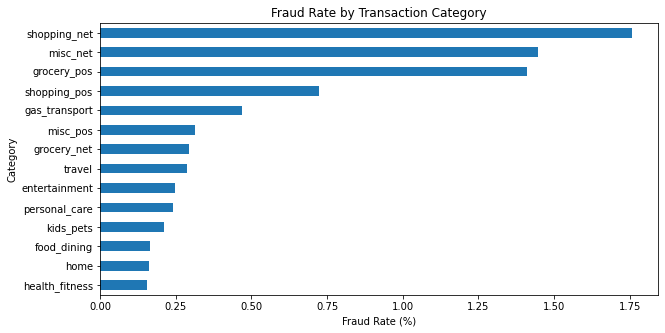

In [6]:
# ============================================================
# EDA: Fraud Rate by Category
# ============================================================

category_fraud_rate = train_df.groupby('category')['is_fraud'].agg(
    ['count', 'mean']
).sort_values('mean', ascending=False)
category_fraud_rate['fraud_rate_percentage'] = category_fraud_rate['mean'] * 100
display(category_fraud_rate)

plt.figure(figsize=(10, 5))
category_fraud_rate['fraud_rate_percentage'].sort_values().plot(kind='barh')
plt.title('Fraud Rate by Transaction Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')
plt.show()

,count,mean,fraud_rate_percentage
gender,,,
F,709863,0.005262,0.526158
M,586812,0.006426,0.642625


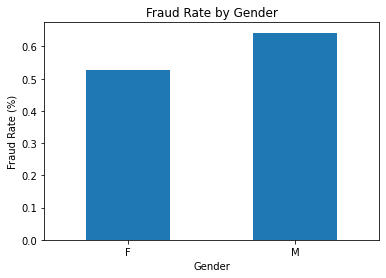

In [7]:
# ============================================================
# EDA: Fraud Rate by Gender
# ============================================================

gender_fraud_rate = train_df.groupby('gender')['is_fraud'].agg(['count', 'mean'])
gender_fraud_rate['fraud_rate_percentage'] = gender_fraud_rate['mean'] * 100
display(gender_fraud_rate)

plt.figure(figsize=(6, 4))
gender_fraud_rate['fraud_rate_percentage'].plot(kind='bar')
plt.title('Fraud Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [8]:
# ============================================================
#Feature Engineering
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """Distance between customer and merchant (km)."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))


def feature_engineering(df):
    data = df.copy()
    data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
    data['dob'] = pd.to_datetime(data['dob'])

    data['trans_hour']      = data['trans_date_trans_time'].dt.hour
    data['trans_dayofweek'] = data['trans_date_trans_time'].dt.dayofweek
    data['trans_month']     = data['trans_date_trans_time'].dt.month
    data['trans_day']       = data['trans_date_trans_time'].dt.day
    data['age']             = data['trans_date_trans_time'].dt.year - data['dob'].dt.year
    data['amt_log']         = np.log1p(data['amt'])
    data['distance_km']     = haversine_distance(
        data['lat'], data['long'], data['merch_lat'], data['merch_long']
    )
    return data


train_fe = feature_engineering(train_df)
test_fe  = feature_engineering(test_df)

print('Train shape after feature engineering:', train_fe.shape)
print('Test shape after feature engineering: ', test_fe.shape)
display(train_fe.head())

Train shape after feature engineering: (1296675, 30)
Test shape after feature engineering:  (555719, 30)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,trans_day,age,amt_log,distance_km
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.011293,-82.048315,0,0,1,1,1,31,1.786747,78.597568
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,49.159047,-118.186462,0,0,1,1,1,41,4.684259,30.212176
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,43.150704,-112.154481,0,0,1,1,1,57,5.398660,108.206083
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,47.034331,-112.561071,0,0,1,1,1,52,3.828641,95.673231
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.674999,-78.632459,0,0,1,1,1,33,3.760269,77.556744


In [9]:
# ============================================================
# Drop Columns & Prepare X / y
# ============================================================

drop_columns = [
    'Unnamed: 0', 'trans_date_trans_time', 'cc_num',
    'first', 'last', 'street', 'dob', 'trans_num', 'unix_time'
]
drop_columns = [c for c in drop_columns if c in train_fe.columns]

target = 'is_fraud'

X_train = train_fe.drop(columns=drop_columns + [target])
y_train = train_fe[target].astype(int)

X_test  = test_fe.drop(columns=drop_columns + [target])
y_test  = test_fe[target].astype(int)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
display(X_train.head())

X_train shape: (1296675, 20)
X_test shape:  (555719, 20)


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,trans_hour,trans_dayofweek,trans_month,trans_day,age,amt_log,distance_km
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,1,1,1,31,1.786747,78.597568
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,1,1,1,41,4.684259,30.212176
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,1,1,1,57,5.398660,108.206083
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071,0,1,1,1,52,3.828641,95.673231
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459,0,1,1,1,33,3.760269,77.556744


In [10]:
# ============================================================
# Identify Numeric & Categorical Features
# ============================================================

numeric_features     = X_train.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()

print('Numeric features:')
print(numeric_features)
print('\nCategorical features:')
print(categorical_features)

Numeric features:
['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'trans_hour', 'trans_dayofweek', 'trans_month', 'trans_day', 'age', 'amt_log', 'distance_km']

Categorical features:
['merchant', 'category', 'gender', 'city', 'state', 'job']


In [11]:
# ============================================================
# Preprocessing Pipelines
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# For Logistic Regression: One-Hot Encoding 
categorical_transformer_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor_ohe = ColumnTransformer([
    ('num', numeric_transformer,           numeric_features),
    ('cat', categorical_transformer_ohe,   categorical_features)
])

# For Tree Models: Ordinal Encoding (faster) 
categorical_transformer_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_transformer,              numeric_features),
    ('cat', categorical_transformer_ordinal,  categorical_features)
])

print('Preprocessors ready.')

Preprocessors ready.


In [12]:
# ============================================================
#  Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    cm      = confusion_matrix(y_test, y_pred)

    metrics = {
        'Model':            model_name,
        'Threshold':        threshold,
        'Accuracy':         accuracy_score(y_test, y_pred),
        'Precision':        precision_score(y_test, y_pred, zero_division=0),
        'Recall':           recall_score(y_test, y_pred, zero_division=0),
        'F1-score':         f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':          roc_auc_score(y_test, y_proba),
        'PR-AUC':           average_precision_score(y_test, y_proba),
        'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0], 'TP': cm[1,1],
        'Fraud Predictions': y_pred.sum()
    }

    print('=' * 90)
    print(model_name)
    print('=' * 90)
    print(f'Threshold used: {threshold}')
    print('\nPrediction counts:')
    print(pd.Series(y_pred).value_counts().rename(index={0:'Not Fraud', 1:'Fraud'}))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Not Fraud','Fraud'], zero_division=0))

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud','Fraud']).plot(values_format='d')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f'ROC Curve — {model_name}')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f'Precision-Recall Curve — {model_name}')
    plt.show()

    return metrics

print('evaluate_model() defined.')

evaluate_model() defined.


Dummy Classifier
Threshold used: 0.5

Prediction counts:
Not Fraud    555719
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



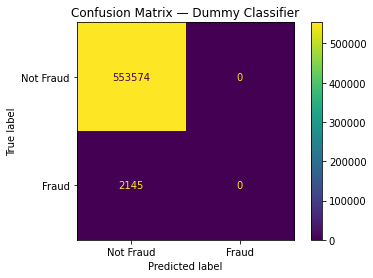

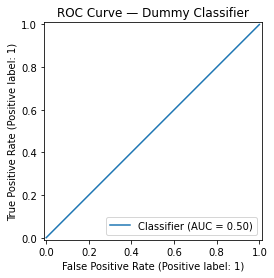

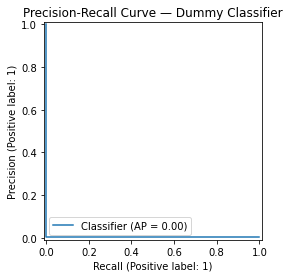

In [13]:
# ============================================================
# Baseline: Dummy Classifier
# ============================================================

dummy_model = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('model', DummyClassifier(strategy='most_frequent'))
])

dummy_model.fit(X_train, y_train)

dummy_metrics = evaluate_model(
    dummy_model, X_test, y_test,
    model_name='Dummy Classifier', threshold=0.5
)

Logistic Regression - Balanced
Threshold used: 0.5

Prediction counts:
Not Fraud    518560
Fraud         37159
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.93      0.96    553574
       Fraud       0.02      0.32      0.04      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.63      0.50    555719
weighted avg       0.99      0.93      0.96    555719



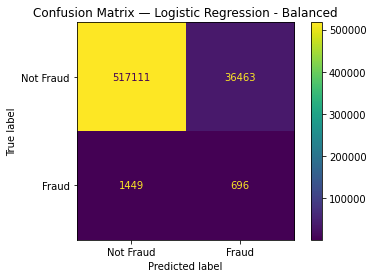

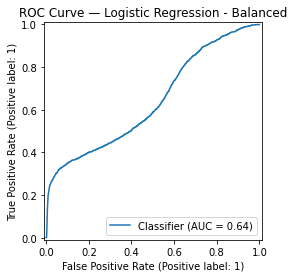

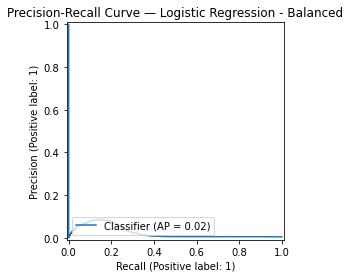

In [15]:
# ============================================================
#  Model 1: Logistic Regression (Balanced)
# ============================================================

logistic_model = Pipeline([
    ('preprocessor', preprocessor_ohe),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)

logistic_metrics = evaluate_model(
    logistic_model, X_test, y_test,
    model_name='Logistic Regression - Balanced', threshold=0.5
)

Random Forest - Balanced
Threshold used: 0.5

Prediction counts:
Not Fraud    552640
Fraud          3079
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.57      0.81      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.78      0.91      0.83    555719
weighted avg       1.00      1.00      1.00    555719



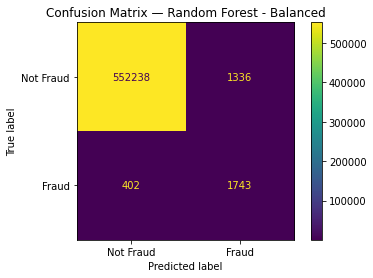

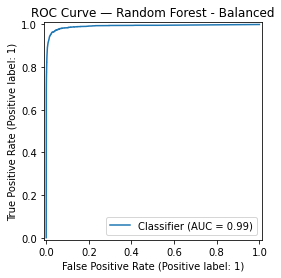

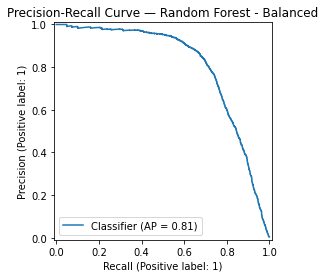

In [16]:
# ============================================================
#  Model 2: Random Forest (Balanced Subsample)
# ============================================================

rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(
    rf_model, X_test, y_test,
    model_name='Random Forest - Balanced', threshold=0.5
)

XGBoost scale_pos_weight: 171.75179856115108
XGBoost - Weighted
Threshold used: 0.5

Prediction counts:
Not Fraud    547491
Fraud          8228
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99    553574
       Fraud       0.25      0.95      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.97      0.69    555719
weighted avg       1.00      0.99      0.99    555719



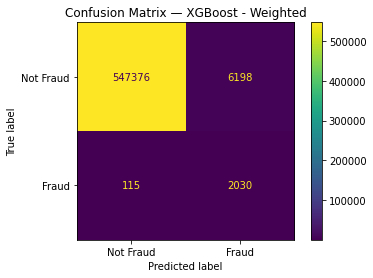

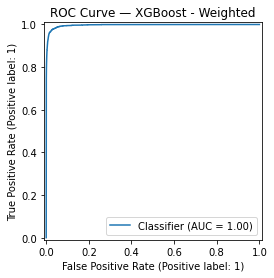

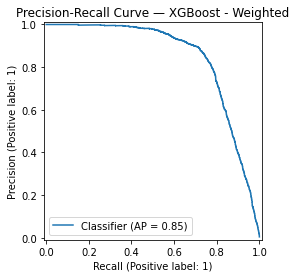

In [18]:
# ============================================================
#  Model 3: XGBoost (Optional)
# ============================================================


xgb_model   = None
xgb_metrics = None

try:
    from xgboost import XGBClassifier

    fraud_count     = y_train.sum()
    not_fraud_count = len(y_train) - fraud_count
    scale_pos_weight = not_fraud_count / fraud_count
    print('XGBoost scale_pos_weight:', scale_pos_weight)

    xgb_model = Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            objective='binary:logistic',
            eval_metric='aucpr',
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_model.fit(X_train, y_train)

    xgb_metrics = evaluate_model(
        xgb_model, X_test, y_test,
        model_name='XGBoost - Weighted', threshold=0.5
    )

except Exception as e:
    print('XGBoost not available or failed:', e)

Logistic Regression + SMOTE
Threshold used: 0.5

Prediction counts:
Not Fraud    519615
Fraud         36104
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.94      0.97    553574
       Fraud       0.01      0.25      0.03      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.59      0.50    555719
weighted avg       0.99      0.93      0.96    555719



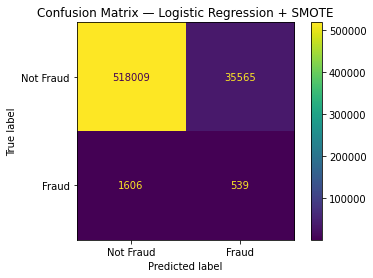

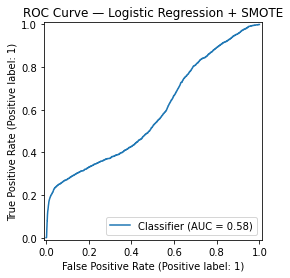

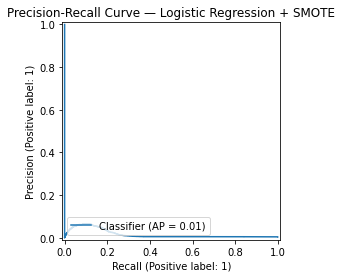

In [19]:
# ============================================================
#  Model 4: SMOTE + Logistic Regression (Optional)
# ============================================================
# Install if needed:  pip install imbalanced-learn

smote_model   = None
smote_metrics = None

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

    smote_model = ImbPipeline([
        ('preprocessor', preprocessor_ohe),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=3000, random_state=42, n_jobs=-1))
    ])

    smote_model.fit(X_train, y_train)

    smote_metrics = evaluate_model(
        smote_model, X_test, y_test,
        model_name='Logistic Regression + SMOTE', threshold=0.5
    )

except Exception as e:
    print('SMOTE not available or failed:', e)

In [20]:
# ============================================================
# Select Best Base Model for Threshold Tuning
# ============================================================

if xgb_model is not None:
    best_base_model = xgb_model
    best_model_name = 'XGBoost - Weighted'
else:
    best_base_model = rf_model
    best_model_name = 'Random Forest - Balanced'

print('Best base model for threshold tuning:', best_model_name)

Best base model for threshold tuning: XGBoost - Weighted


Fraud probability statistics:
  Min:    3.133359e-06
  Max:    0.9996146
  Mean:   0.025243958
  Median: 0.0012775103


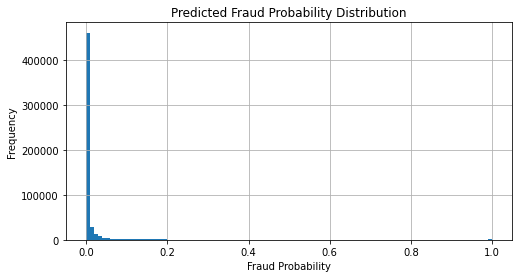

In [ ]:
# ============================================================
# Probability Distribution Check
# ============================================================

y_proba = best_base_model.predict_proba(X_test)[:, 1]

print('Fraud probability statistics:')
print('  Min:   ', y_proba.min())
print('  Max:   ', y_proba.max())
print('  Mean:  ', y_proba.mean())
print('  Median:', np.median(y_proba))

plt.figure(figsize=(8, 4))
pd.Series(y_proba).hist(bins=100)
plt.title('Predicted Fraud Probability Distribution')
plt.xlabel('Fraud Probability')
plt.ylabel('Frequency')
plt.show()

In [22]:
# ============================================================
# Default Threshold 0.5 Evaluation
# ============================================================

y_pred_default = (y_proba >= 0.5).astype(int)

print('Prediction counts with threshold 0.5:')
print(pd.Series(y_pred_default).value_counts().rename(index={0:'Not Fraud', 1:'Fraud'}))

print('\nConfusion Matrix with threshold 0.5:')
print(confusion_matrix(y_test, y_pred_default))

print('\nClassification Report with threshold 0.5:')
print(classification_report(y_test, y_pred_default, target_names=['Not Fraud','Fraud'], zero_division=0))

Prediction counts with threshold 0.5:
Not Fraud    547491
Fraud          8228
Name: count, dtype: int64

Confusion Matrix with threshold 0.5:
[[547376   6198]
 [   115   2030]]

Classification Report with threshold 0.5:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99    553574
       Fraud       0.25      0.95      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.97      0.69    555719
weighted avg       1.00      0.99      0.99    555719



Best threshold (F1): 0.9650
Precision:           0.8639
Recall:              0.7399
F1-score:            0.7971


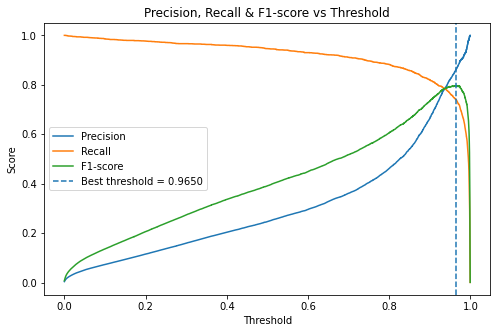

In [23]:
# ============================================================
# Find Best Threshold Using F1-score
# ============================================================

precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba)

prec_t = precision_arr[:-1]
rec_t  = recall_arr[:-1]

f1_scores = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Best threshold (F1): {best_threshold:.4f}')
print(f'Precision:           {prec_t[best_idx]:.4f}')
print(f'Recall:              {rec_t[best_idx]:.4f}')
print(f'F1-score:            {f1_scores[best_idx]:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(thresholds, prec_t,   label='Precision')
plt.plot(thresholds, rec_t,    label='Recall')
plt.plot(thresholds, f1_scores, label='F1-score')
plt.axvline(best_threshold, linestyle='--', label=f'Best threshold = {best_threshold:.4f}')
plt.title('Precision, Recall & F1-score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

XGBoost - Weighted - Tuned Threshold
Threshold used: 0.9649665951728821

Prediction counts:
Not Fraud    553882
Fraud          1837
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.86      0.74      0.80      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.87      0.90    555719
weighted avg       1.00      1.00      1.00    555719



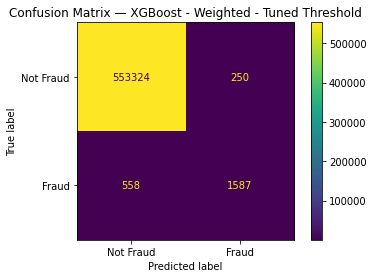

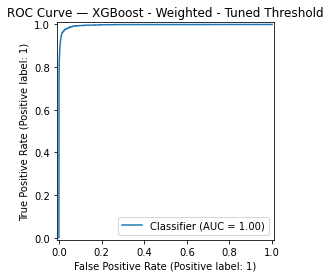

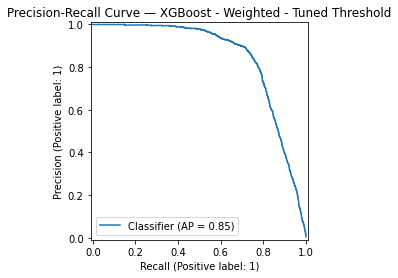

In [24]:
# ============================================================
#  Evaluate Best Model with Tuned Threshold
# ============================================================

tuned_metrics = evaluate_model(
    best_base_model, X_test, y_test,
    model_name=f'{best_model_name} - Tuned Threshold',
    threshold=best_threshold
)

,Threshold,Fraud Predictions,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.50,8228,0.988640,0.246719,0.946387,0.391401,547376,6198,115,2030
1,0.30,13017,0.980177,0.159253,0.966434,0.273447,542630,10944,72,2073
2,0.20,18200,0.970933,0.115165,0.977156,0.206046,537470,16104,49,2096
3,0.10,28950,0.951657,0.073057,0.986014,0.136035,526739,26835,30,2115
4,0.05,41701,0.928759,0.051030,0.992075,0.097067,514001,39573,17,2128
5,0.02,67493,0.882376,0.031648,0.995804,0.061346,488217,65357,9,2136
6,0.01,95691,0.831649,0.022364,0.997669,0.043747,460023,93551,5,2140


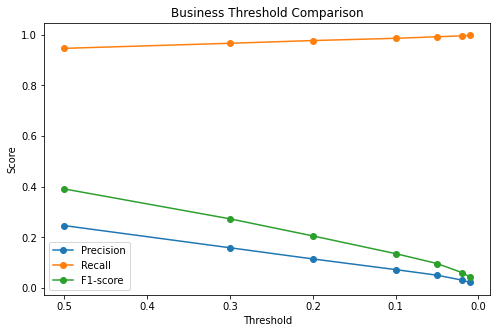

In [25]:
# ============================================================
# Business Threshold Comparison
# ============================================================

business_thresholds = [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]
threshold_rows = []

for th in business_thresholds:
    y_pred_th = (y_proba >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)
    threshold_rows.append({
        'Threshold':         th,
        'Fraud Predictions': y_pred_th.sum(),
        'Accuracy':          accuracy_score(y_test, y_pred_th),
        'Precision':         precision_score(y_test, y_pred_th, zero_division=0),
        'Recall':            recall_score(y_test, y_pred_th, zero_division=0),
        'F1-score':          f1_score(y_test, y_pred_th, zero_division=0),
        'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0], 'TP': cm[1,1]
    })

threshold_comparison = pd.DataFrame(threshold_rows)
display(threshold_comparison)

plt.figure(figsize=(8, 5))
plt.plot(threshold_comparison['Threshold'], threshold_comparison['Precision'], marker='o', label='Precision')
plt.plot(threshold_comparison['Threshold'], threshold_comparison['Recall'],    marker='o', label='Recall')
plt.plot(threshold_comparison['Threshold'], threshold_comparison['F1-score'],  marker='o', label='F1-score')
plt.gca().invert_xaxis()
plt.title('Business Threshold Comparison')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

In [ ]:
# ============================================================
# CELL 26 — Top 30 Suspicious Transactions
# ============================================================

fraud_review_table = X_test.copy()
fraud_review_table['Actual']           = y_test.values
fraud_review_table['Fraud Probability'] = y_proba
fraud_review_table['Prediction Tuned'] = (y_proba >= best_threshold).astype(int)
fraud_review_table['Prediction Label'] = fraud_review_table['Prediction Tuned'].map({0:'Not Fraud', 1:'Fraud'})

top_suspicious = fraud_review_table.sort_values('Fraud Probability', ascending=False).head(30)

display(top_suspicious[['Fraud Probability','Prediction Tuned','Prediction Label','Actual']])

In [26]:
# ============================================================
# Final Check: Did the Model Predict Fraud?
# ============================================================

y_pred_tuned          = (y_proba >= best_threshold).astype(int)
fraud_predicted_count = y_pred_tuned.sum()

if fraud_predicted_count == 0:
    print('''
WARNING: The model still predicts zero fraud cases.
Try: lower threshold (0.10, 0.05, 0.02), use XGBoost, use SMOTE, or add more features.
''')
else:
    print(f'SUCCESS: Model predicted {fraud_predicted_count} fraud transactions using tuned threshold ({best_threshold:.4f}).')

SUCCESS: Model predicted 1837 fraud transactions using tuned threshold (0.9650).


In [27]:
# ============================================================
# Model Comparison Table
# ============================================================

all_metrics = [dummy_metrics, logistic_metrics, rf_metrics, tuned_metrics]

if xgb_metrics   is not None: all_metrics.append(xgb_metrics)
if smote_metrics  is not None: all_metrics.append(smote_metrics)

metrics_df = pd.DataFrame(all_metrics).sort_values('PR-AUC', ascending=False)
display(metrics_df)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Fraud Predictions
4,XGBoost - Weighted,0.500000,0.988640,0.246719,0.946387,0.391401,0.996908,0.847494,547376,6198,115,2030,8228
3,XGBoost - Weighted - Tuned Threshold,0.964967,0.998546,0.863909,0.739860,0.797087,0.996908,0.847494,553324,250,558,1587,1837
2,Random Forest - Balanced,0.500000,0.996873,0.566093,0.812587,0.667305,0.992466,0.807470,552238,1336,402,1743,3079
1,Logistic Regression - Balanced,0.500000,0.931778,0.018730,0.324476,0.035416,0.639583,0.022395,517111,36463,1449,696,37159
5,Logistic Regression + SMOTE,0.500000,0.933112,0.014929,0.251282,0.028184,0.584361,0.014915,518009,35565,1606,539,36104
0,Dummy Classifier,0.500000,0.996140,0.000000,0.000000,0.000000,0.500000,0.003860,553574,0,2145,0,0


,Feature,Importance
0,amt,0.343331
12,amt_log,0.320240
7,trans_hour,0.148715
15,category,0.082622
11,age,0.015416
4,city_pop,0.010500
14,merchant,0.007523
5,merch_lat,0.006849
19,job,0.006587
17,city,0.006566


<Figure size 576x576 with 0 Axes>

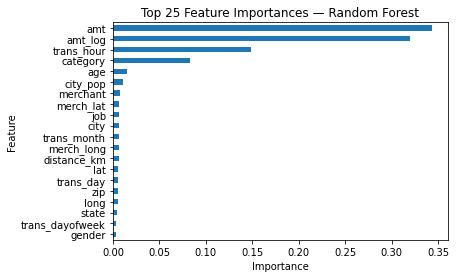

In [28]:
# ============================================================
#  Feature Importance (Random Forest)
# ============================================================

rf_estimator = rf_model.named_steps['model']
feature_names = numeric_features + categorical_features

feature_importance = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_estimator.feature_importances_
}).sort_values('Importance', ascending=False)

display(feature_importance.head(25))

plt.figure(figsize=(8, 8))
feature_importance.head(25).sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance', legend=False
)
plt.title('Top 25 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [31]:
import pickle


best_model = xgb_model   


with open("fraud_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


threshold = 0.965

with open("threshold.pkl", "wb") as f:
    pickle.dump(threshold, f)